# IMPORT DATA

In [95]:
import pandas as pd
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer

from sklearn import set_config
set_config(transform_output='pandas')

In [96]:
all_features_df=pd.read_csv('/content/2_spotify_10_songs.csv')
all_features_df

,song_name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,My Band ...,D12,0.851,0.84900,1,-3.383,0,0.0828,0.49700,0.000002,0.1160,0.8440,120.014,298773,4,4XHQyvbrBsQaaBUW1VvmsL,https://open.spotify.com/track/4XHQyvbrBsQaaBU...
1,The Real Slim Shady ...,Eminem,0.949,0.66100,5,-4.244,0,0.0572,0.03020,0.000000,0.0454,0.7600,104.504,284200,4,3yfqSUWxFvZELEM4PmlwIR,https://open.spotify.com/track/3yfqSUWxFvZELEM...
2,Águas De Março ...,Antônio Carlos Jobim,0.642,0.33900,3,-15.503,1,0.1400,0.85400,0.000000,0.1050,0.4910,143.418,212400,4,1y7OxO5i6sfrHXAmUM77YG,https://open.spotify.com/track/1y7OxO5i6sfrHXA...
3,The Girl From Ipanema ...,Stan Getz,0.641,0.14000,8,-16.790,1,0.0390,0.86700,0.001660,0.1050,0.3880,129.318,317987,4,3898C4AbdbptwYet6547e5,https://open.spotify.com/track/3898C4AbdbptwYe...
4,"Paint It, Black ...",The Rolling Stones,0.464,0.79500,1,-9.267,1,0.0926,0.04930,0.002440,0.3990,0.6120,158.691,202267,4,63T7DJ1AFDD6Bn8VzG6JE8,https://open.spotify.com/track/63T7DJ1AFDD6Bn8...
5,Sultans Of Swing ...,Dire Straits,0.733,0.79400,5,-10.023,1,0.0307,0.06140,0.036700,0.3300,0.9310,148.174,348624,4,6cr6UDpkjEaMQ80OjWqEBQ,https://open.spotify.com/track/6cr6UDpkjEaMQ80...
6,Space Raiders - Charlotte de Witte Remix ...,Eats Everything,0.749,0.73100,4,-10.865,1,0.1080,0.00314,0.867000,0.1110,0.0598,131.997,438720,4,4F8OK7mNa51mKqgHqWQiYm,https://open.spotify.com/track/4F8OK7mNa51mKqg...
7,In Silence ...,Amelie Lens,0.736,0.84500,1,-12.017,1,0.0377,0.00548,0.901000,0.1110,0.1980,128.009,393740,4,2vfSCFvMbpf4hwxt22Wx7b,https://open.spotify.com/track/2vfSCFvMbpf4hwx...
8,"Wiegenlied, Op. 49, No. 4 (Arr. for Cello and ...",Johannes Brahms,0.184,0.00833,3,-33.503,1,0.0519,0.98900,0.596000,0.1040,0.2110,61.541,109800,3,59cPOVxrn3Yjwydl1pullI,https://open.spotify.com/track/59cPOVxrn3Yjwyd...
9,Nocturne en mi bémol majeur opus 9 n°2: Ballad...,Frédéric Chopin,0.387,0.04510,3,-24.698,1,0.0364,0.99000,0.913000,0.1120,0.0710,61.494,268427,4,7n92QzQomRCLlciO14X0kd,https://open.spotify.com/track/7n92QzQomRCLlci...


In [97]:
all_features_df.columns

Index(['song_name                                                               ',
       'artist               ', 'danceability ', 'energy  ', 'key ',
       'loudness ', 'mode ', 'speechiness ', 'acousticness ',
       'instrumentalness ', 'liveness ', 'valence ', 'tempo   ',
       'duration_ms ', 'time_signature ', 'id                     ', 'html'],
      dtype='object')

In [98]:
all_features_df.columns=all_features_df.columns.str.strip().copy()
all_features_df.columns

Index(['song_name', 'artist', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'id', 'html'],
      dtype='object')

# SELECTING FEATURES

In [99]:
features = ['danceability', 'energy', 'acousticness', 'valence', 'tempo']
selected_features_df=all_features_df[features]
selected_features_df

,danceability,energy,acousticness,valence,tempo
0,0.851,0.84900,0.49700,0.8440,120.014
1,0.949,0.66100,0.03020,0.7600,104.504
2,0.642,0.33900,0.85400,0.4910,143.418
3,0.641,0.14000,0.86700,0.3880,129.318
4,0.464,0.79500,0.04930,0.6120,158.691
5,0.733,0.79400,0.06140,0.9310,148.174
6,0.749,0.73100,0.00314,0.0598,131.997
7,0.736,0.84500,0.00548,0.1980,128.009
8,0.184,0.00833,0.98900,0.2110,61.541
9,0.387,0.04510,0.99000,0.0710,61.494


### WITH_TEMPO

In [100]:
with_tempo_df=selected_features_df
with_tempo_df

,danceability,energy,acousticness,valence,tempo
0,0.851,0.84900,0.49700,0.8440,120.014
1,0.949,0.66100,0.03020,0.7600,104.504
2,0.642,0.33900,0.85400,0.4910,143.418
3,0.641,0.14000,0.86700,0.3880,129.318
4,0.464,0.79500,0.04930,0.6120,158.691
5,0.733,0.79400,0.06140,0.9310,148.174
6,0.749,0.73100,0.00314,0.0598,131.997
7,0.736,0.84500,0.00548,0.1980,128.009
8,0.184,0.00833,0.98900,0.2110,61.541
9,0.387,0.04510,0.99000,0.0710,61.494


### WITHOUT_TEMPO

In [101]:
no_tempo_df = with_tempo_df.drop(columns='tempo')
no_tempo_df

,danceability,energy,acousticness,valence
0,0.851,0.84900,0.49700,0.8440
1,0.949,0.66100,0.03020,0.7600
2,0.642,0.33900,0.85400,0.4910
3,0.641,0.14000,0.86700,0.3880
4,0.464,0.79500,0.04930,0.6120
5,0.733,0.79400,0.06140,0.9310
6,0.749,0.73100,0.00314,0.0598
7,0.736,0.84500,0.00548,0.1980
8,0.184,0.00833,0.98900,0.2110
9,0.387,0.04510,0.99000,0.0710


# HEATMAPS_COMPARING

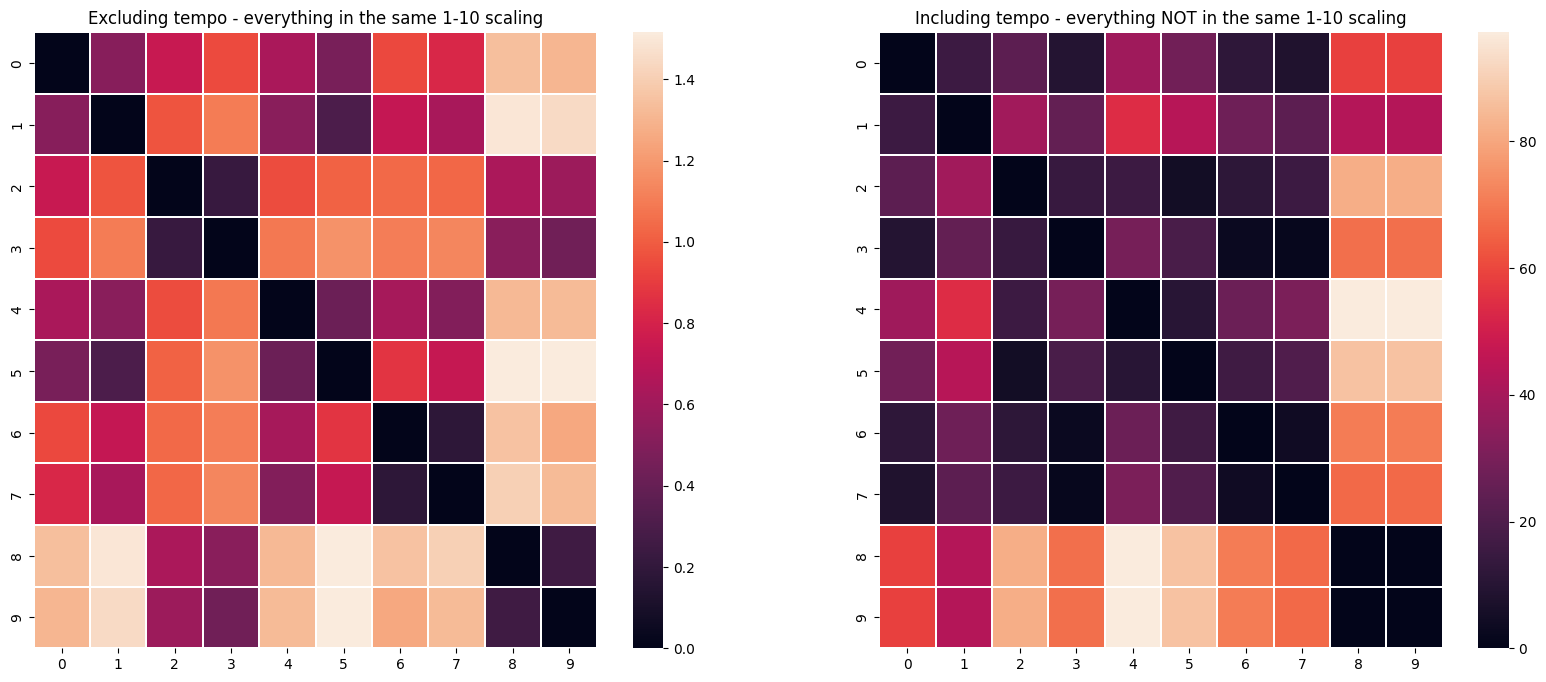

In [102]:
no_tempo_distances_df = pd.DataFrame(pairwise_distances(no_tempo_df),
                                     index=no_tempo_df.index,
                                     columns=no_tempo_df.index)

with_tempo_distances_df = pd.DataFrame(pairwise_distances(with_tempo_df),
                                       index=no_tempo_df.index,
                                       columns=no_tempo_df.index)
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,8))
sns.heatmap(no_tempo_distances_df, ax=ax1, linewidths=.2)
sns.heatmap(with_tempo_distances_df, ax=ax2, linewidths=.2)
ax1.set_title('Excluding tempo - everything in the same 1-10 scaling')
ax2.set_title('Including tempo - everything NOT in the same 1-10 scaling')
plt.show()

# SCALERS

## MIN-MAX SCALER

In [103]:
scaler = MinMaxScaler()
with_tempo_minmax = scaler.fit_transform(selected_features_df)
with_tempo_minmax

,danceability,energy,acousticness,valence,tempo
0,0.871895,1.000000,0.500436,0.900138,0.602076
1,1.000000,0.776369,0.027420,0.803719,0.442503
2,0.598693,0.393341,0.862189,0.494949,0.842866
3,0.597386,0.156625,0.875362,0.376722,0.697799
4,0.366013,0.935766,0.046775,0.633838,1.000000
5,0.717647,0.934576,0.059036,1.000000,0.891797
6,0.738562,0.859636,0.000000,0.000000,0.725362
7,0.721569,0.995242,0.002371,0.158632,0.684332
8,0.000000,0.000000,0.998987,0.173554,0.000484
9,0.265359,0.043739,1.000000,0.012856,0.000000


In [104]:
pd.DataFrame({
    'original_tempo':selected_features_df.iloc[:,-1],
    'min_max_scale_tempo':with_tempo_minmax.iloc[:,-1]
}).sort_values(by='original_tempo')

,original_tempo,min_max_scale_tempo
9,61.494,0.000000
8,61.541,0.000484
1,104.504,0.442503
0,120.014,0.602076
7,128.009,0.684332
3,129.318,0.697799
6,131.997,0.725362
2,143.418,0.842866
5,148.174,0.891797
4,158.691,1.000000


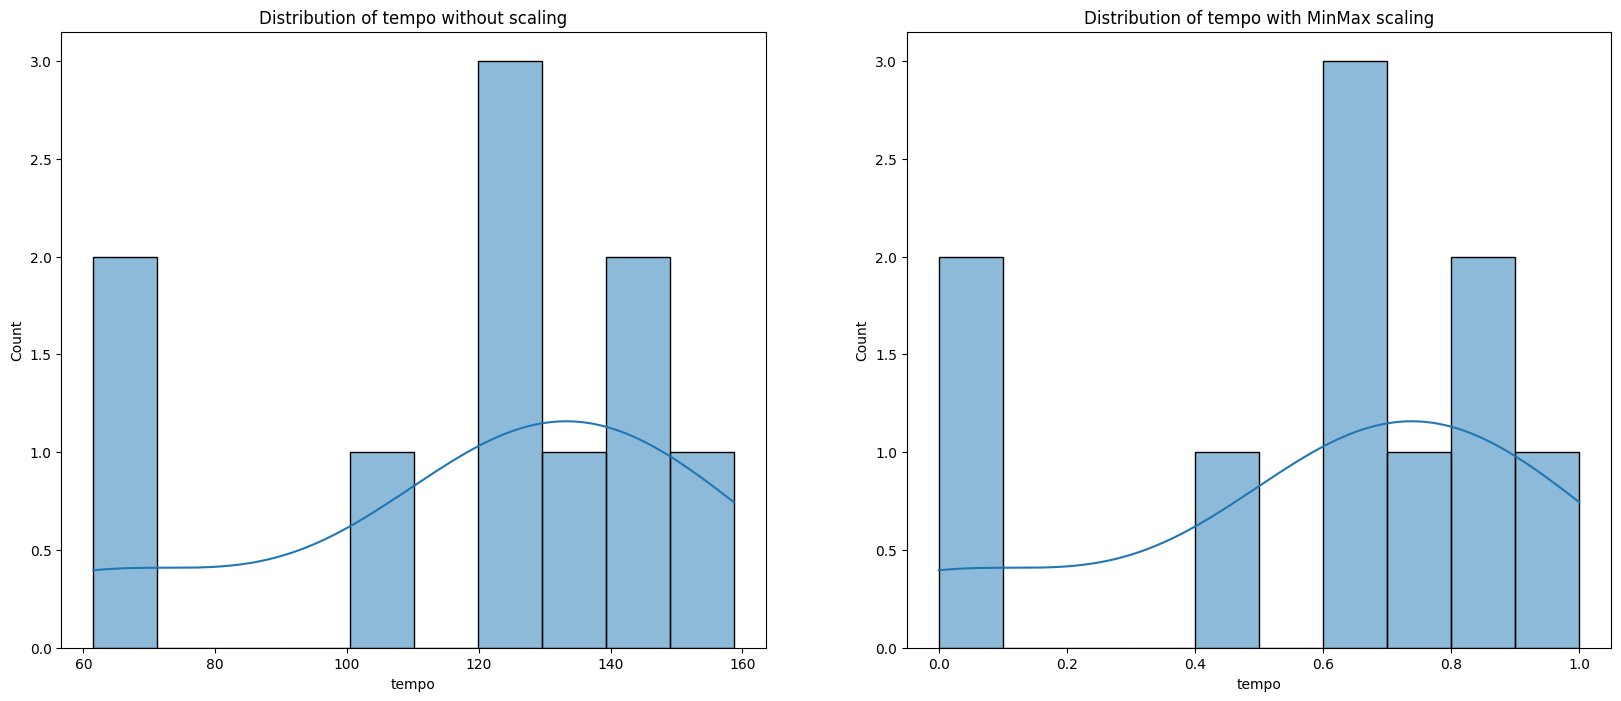

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(data=selected_features_df.iloc[:,-1], bins=10, kde=True, ax=ax1);
sns.histplot(with_tempo_minmax.iloc[:,-1], bins=10, kde=True, ax=ax2);

ax1.set_title('Distribution of tempo without scaling')
ax2.set_title('Distribution of tempo with MinMax scaling')

plt.show()

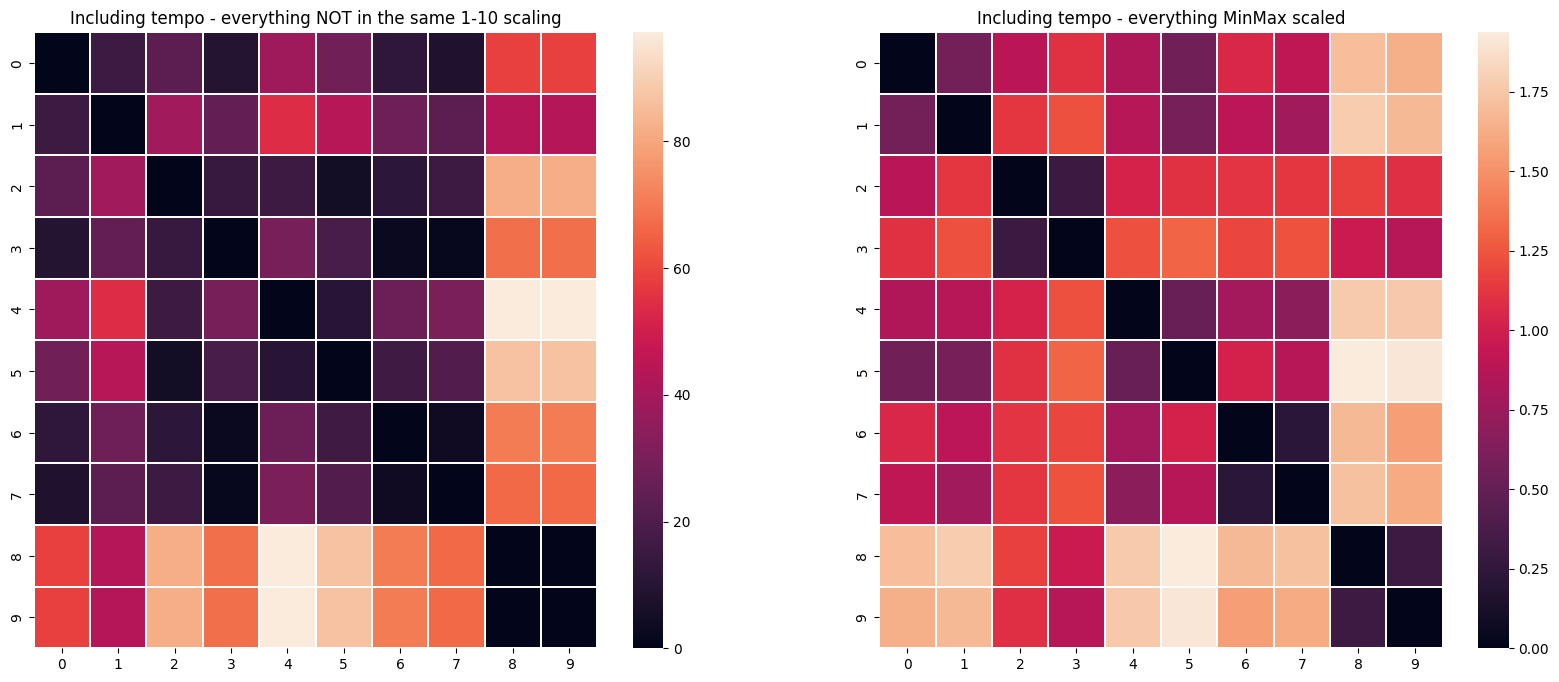

In [106]:
with_tempo_minmax_distances = pd.DataFrame(pairwise_distances(with_tempo_minmax),
                                         index=selected_features_df.index,
                                         columns=selected_features_df.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(with_tempo_distances_df, ax=ax1, linewidths=.2);
sns.heatmap(with_tempo_minmax_distances, ax=ax2, linewidths=.2);

ax1.set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax2.set_title('Including tempo - everything MinMax scaled')

plt.show()

## STANDARD SCALER

In [107]:
scaler = StandardScaler()
with_tempo_standard = scaler.fit_transform(selected_features_df)
with_tempo_standard

,danceability,energy,acousticness,valence,tempo
0,1.000384,0.992687,0.146786,1.270021,0.040646
1,1.451340,0.424153,-0.952202,0.994657,-0.445036
2,0.038653,-0.549612,0.987271,0.112834,0.773521
3,0.034052,-1.151411,1.017877,-0.224816,0.331992
4,-0.780429,0.829385,-0.907235,0.509490,1.251782
5,0.457397,0.826361,-0.878748,1.555220,0.922451
6,0.531023,0.635842,-1.015909,-1.300705,0.415883
7,0.471202,0.980591,-1.010400,-0.847664,0.291002
8,-2.068872,-1.549596,1.305102,-0.805048,-1.790384
9,-1.134751,-1.438400,1.307456,-1.263989,-1.791856


In [108]:
pd.DataFrame({
    'original_tempo': selected_features_df.iloc[:,-1],
    'standard_scale_tempo': with_tempo_standard.iloc[:,-1]
}).sort_values(by='original_tempo')

,original_tempo,standard_scale_tempo
9,61.494,-1.791856
8,61.541,-1.790384
1,104.504,-0.445036
0,120.014,0.040646
7,128.009,0.291002
3,129.318,0.331992
6,131.997,0.415883
2,143.418,0.773521
5,148.174,0.922451
4,158.691,1.251782


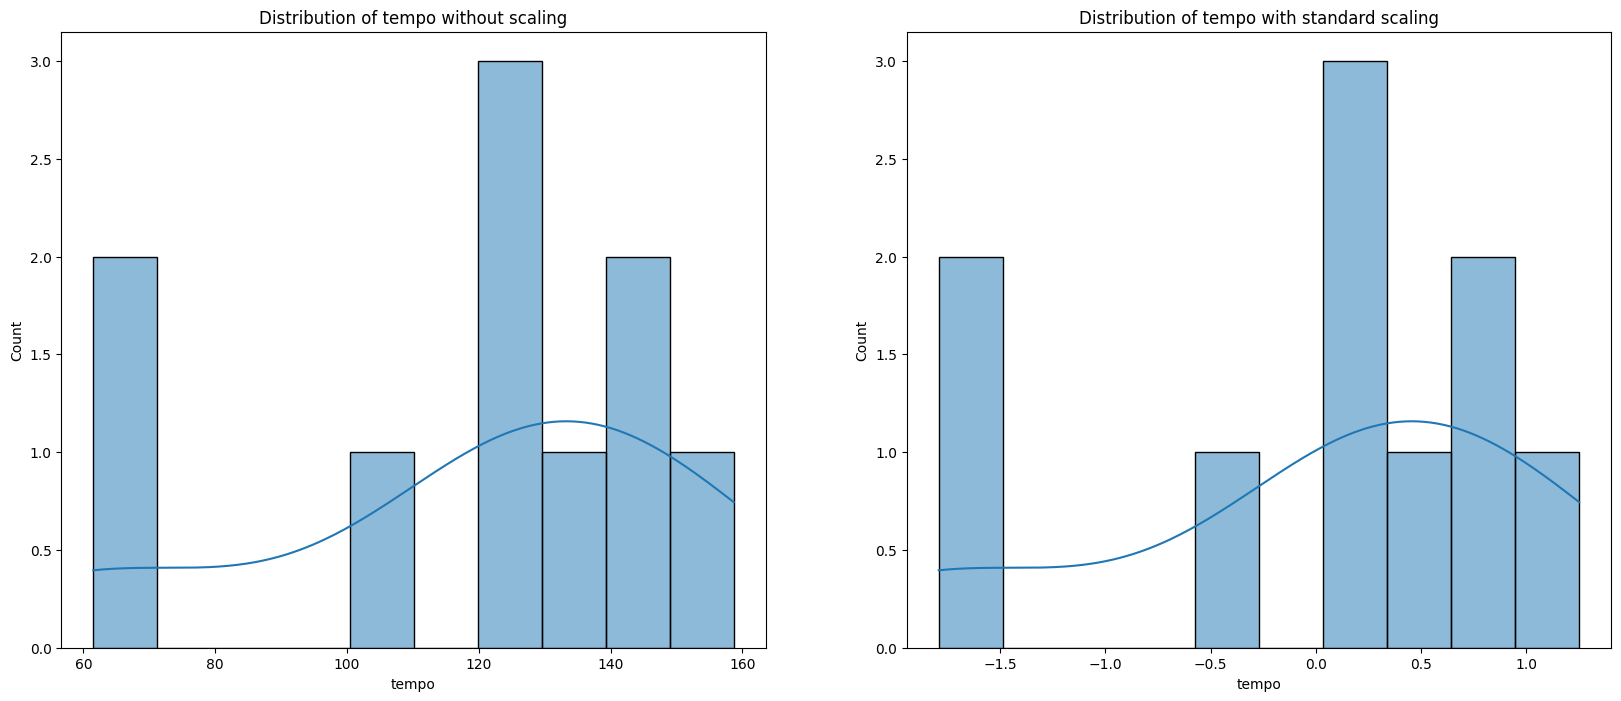

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(data=selected_features_df.iloc[:,-1], bins=10, kde=True, ax=ax1);
sns.histplot(with_tempo_standard.iloc[:,-1], bins=10, kde=True, ax=ax2);

ax1.set_title('Distribution of tempo without scaling')
ax2.set_title('Distribution of tempo with standard scaling')

plt.show()

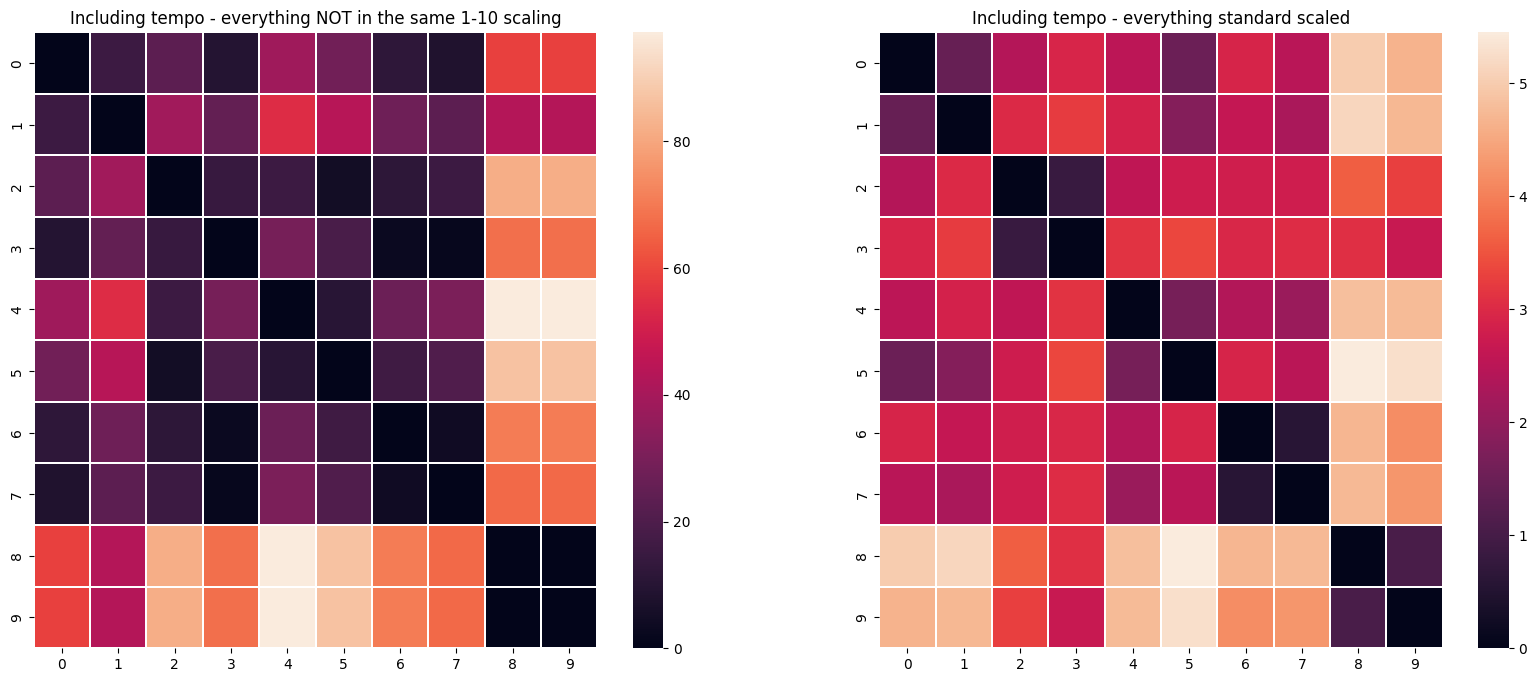

In [110]:
with_tempo_standard_distances = pd.DataFrame(pairwise_distances(with_tempo_standard),
                                         index=selected_features_df.index,
                                         columns=selected_features_df.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(with_tempo_distances_df, ax=ax1, linewidths=.2);
sns.heatmap(with_tempo_standard_distances, ax=ax2, linewidths=.2);

ax1.set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax2.set_title('Including tempo - everything standard scaled')

plt.show()

## ROBUST SCALER

In [111]:
scaler = RobustScaler()
with_tempo_robust = scaler.fit_transform(with_tempo_df)
with_tempo_robust

,danceability,energy,acousticness,valence,tempo
0,0.688421,0.252893,0.262798,0.775276,-0.268775
1,1.101053,-0.057851,-0.300443,0.614279,-0.750732
2,-0.191579,-0.590083,0.693554,0.098706,0.458481
3,-0.195789,-0.919008,0.709240,-0.098706,0.020338
4,-0.941053,0.163636,-0.277397,0.330618,0.933074
5,0.191579,0.161983,-0.262798,0.942022,0.606269
6,0.258947,0.057851,-0.333094,-0.727743,0.103585
7,0.204211,0.246281,-0.330271,-0.462865,-0.020338
8,-2.120000,-1.136645,0.856445,-0.437949,-2.085764
9,-1.265263,-1.075868,0.857651,-0.706277,-2.087225


In [112]:
pd.DataFrame({
    'original_tempo':with_tempo_df.iloc[:,-1],
    'tempo_robust':with_tempo_robust.iloc[:,-1],
})

,original_tempo,tempo_robust
0,120.014,-0.268775
1,104.504,-0.750732
2,143.418,0.458481
3,129.318,0.020338
4,158.691,0.933074
5,148.174,0.606269
6,131.997,0.103585
7,128.009,-0.020338
8,61.541,-2.085764
9,61.494,-2.087225


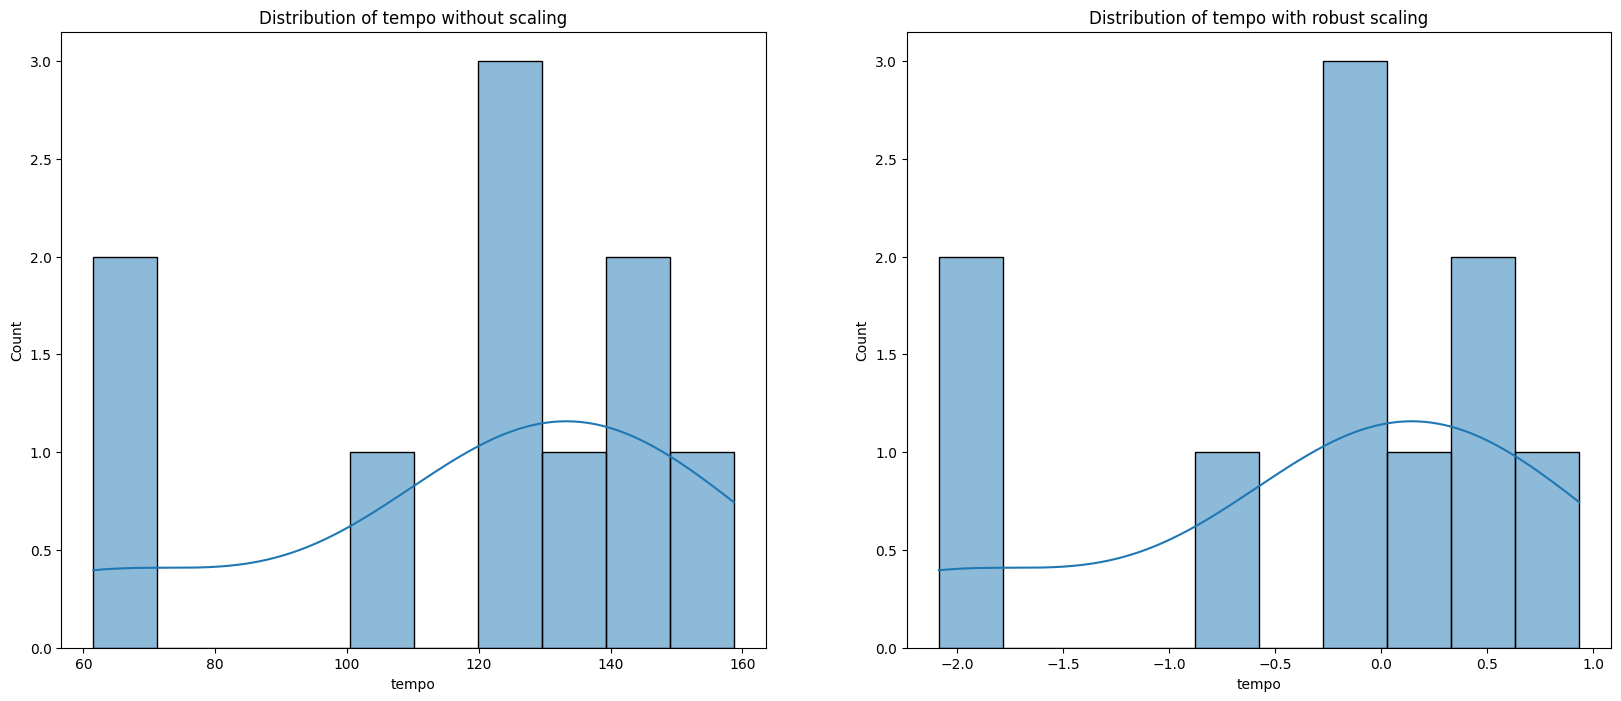

In [113]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(data=selected_features_df.iloc[:,-1], bins=10, kde=True, ax=ax1);
sns.histplot(with_tempo_robust.iloc[:,-1], bins=10, kde=True, ax=ax2);

ax1.set_title('Distribution of tempo without scaling')
ax2.set_title('Distribution of tempo with robust scaling')

plt.show()

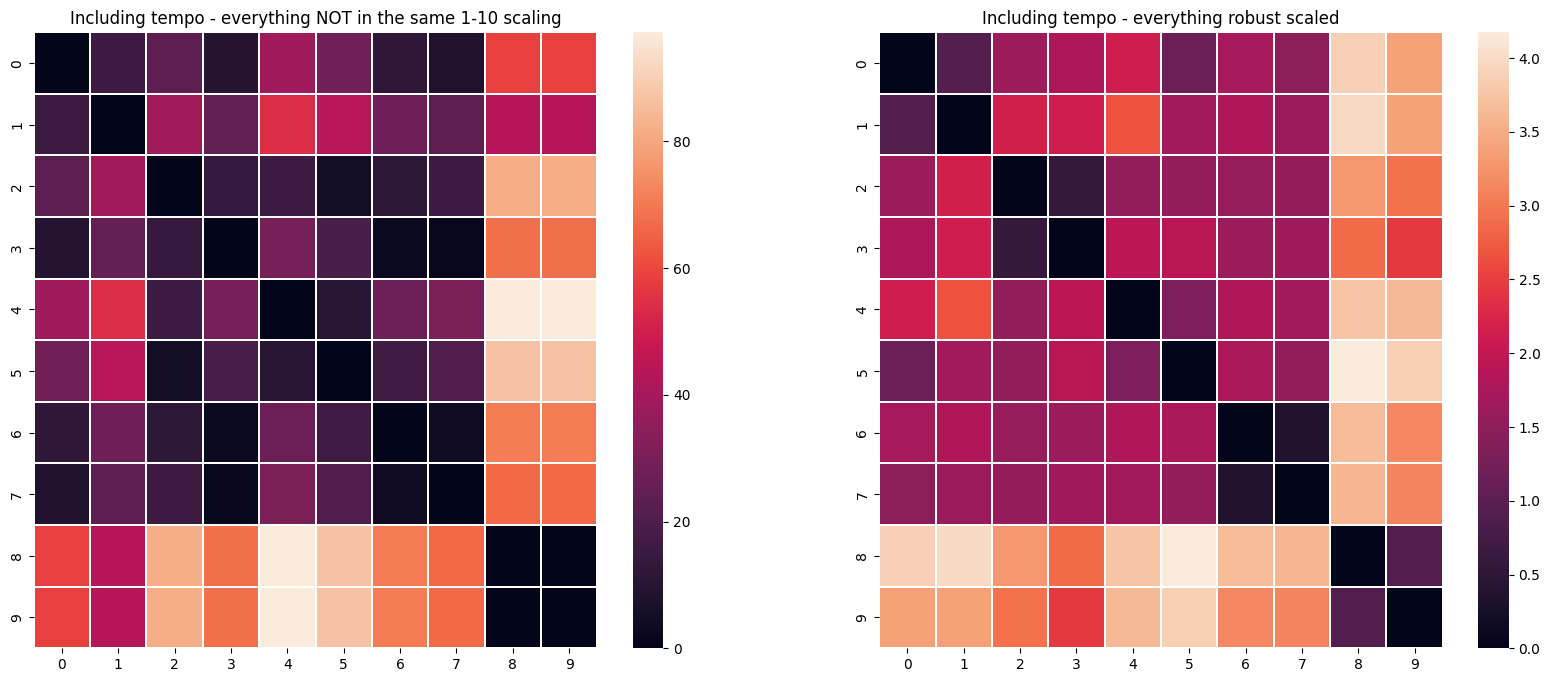

In [114]:
with_tempo_robust_distances = pd.DataFrame(pairwise_distances(with_tempo_robust),
                                         index=selected_features_df.index,
                                         columns=selected_features_df.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(with_tempo_distances_df, ax=ax1, linewidths=.2);
sns.heatmap(with_tempo_robust_distances, ax=ax2, linewidths=.2);

ax1.set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax2.set_title('Including tempo - everything robust scaled')

plt.show()

# TRANSFORMERS

## QUANTILE TRANSFORMER

In [115]:
scale = QuantileTransformer()
with_tempo_quantile=scaler.fit_transform(with_tempo_df)
with_tempo_quantile

,danceability,energy,acousticness,valence,tempo
0,0.688421,0.252893,0.262798,0.775276,-0.268775
1,1.101053,-0.057851,-0.300443,0.614279,-0.750732
2,-0.191579,-0.590083,0.693554,0.098706,0.458481
3,-0.195789,-0.919008,0.709240,-0.098706,0.020338
4,-0.941053,0.163636,-0.277397,0.330618,0.933074
5,0.191579,0.161983,-0.262798,0.942022,0.606269
6,0.258947,0.057851,-0.333094,-0.727743,0.103585
7,0.204211,0.246281,-0.330271,-0.462865,-0.020338
8,-2.120000,-1.136645,0.856445,-0.437949,-2.085764
9,-1.265263,-1.075868,0.857651,-0.706277,-2.087225


In [116]:
pd.DataFrame({
    'original_tempo':with_tempo_df.iloc[:,-1],
    'tempo_quantile':with_tempo_quantile.iloc[:,-1],
})

,original_tempo,tempo_quantile
0,120.014,-0.268775
1,104.504,-0.750732
2,143.418,0.458481
3,129.318,0.020338
4,158.691,0.933074
5,148.174,0.606269
6,131.997,0.103585
7,128.009,-0.020338
8,61.541,-2.085764
9,61.494,-2.087225


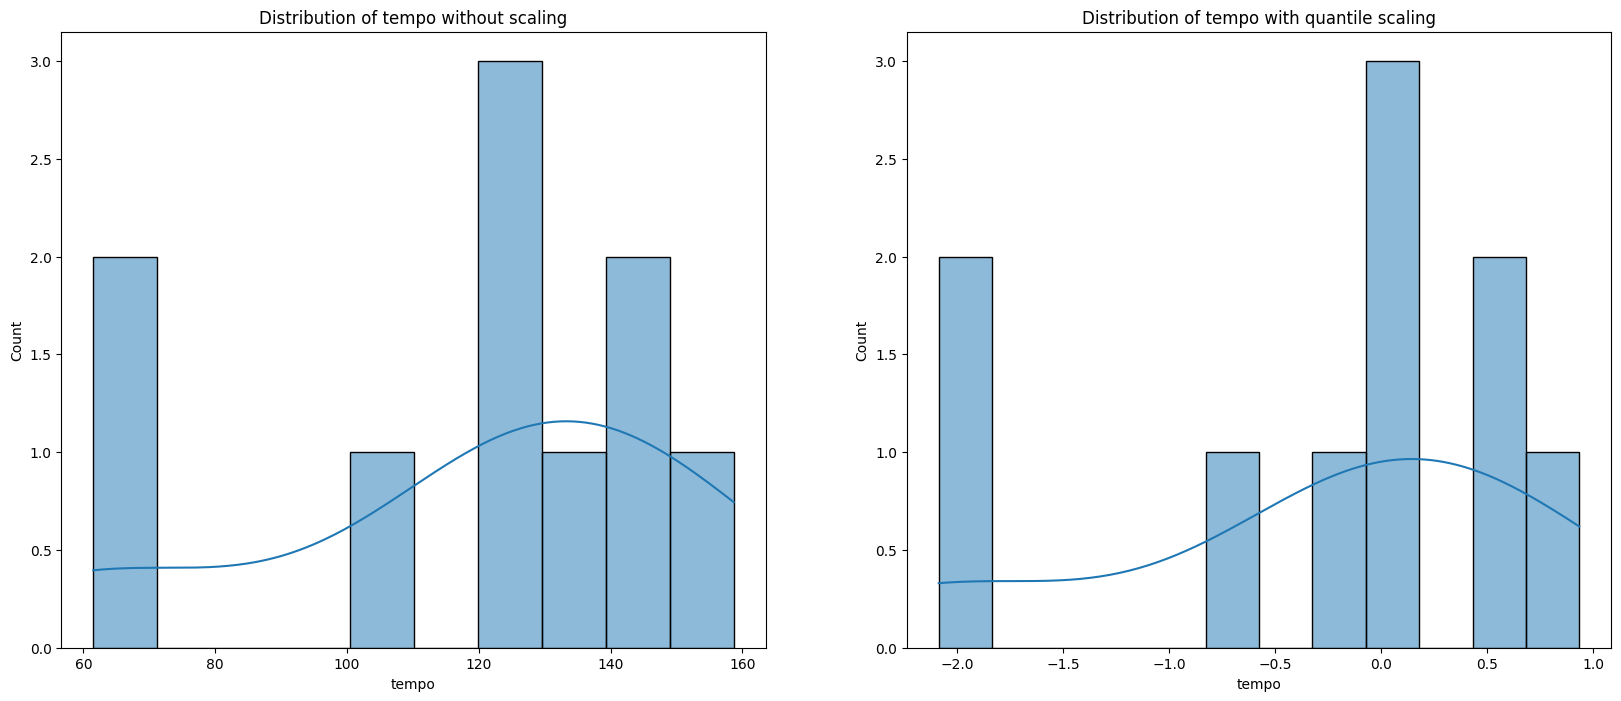

In [117]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(data=selected_features_df.iloc[:,-1], bins=10, kde=True, ax=ax1);
sns.histplot(with_tempo_quantile.iloc[:,-1], bins=12, kde=True, ax=ax2);

ax1.set_title('Distribution of tempo without scaling')
ax2.set_title('Distribution of tempo with quantile scaling')

plt.show()

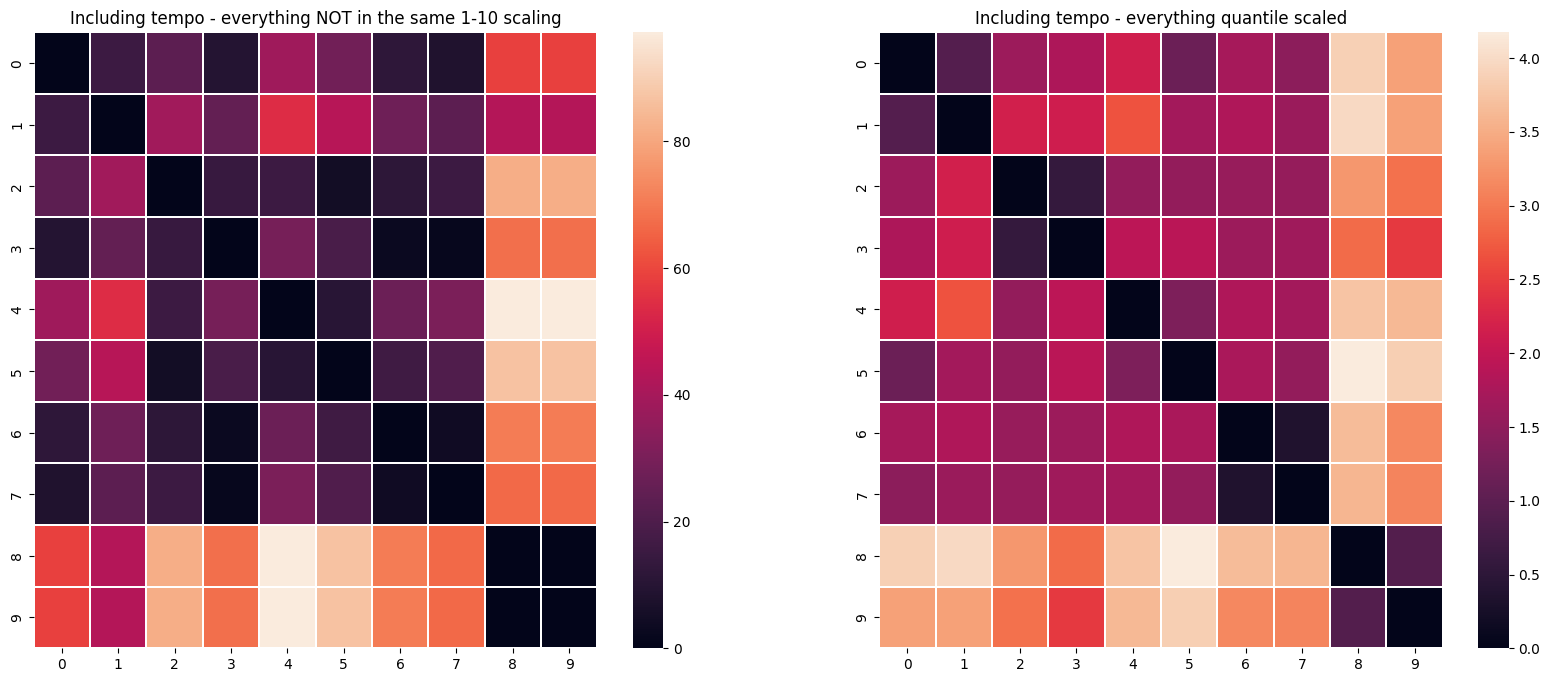

In [118]:
with_tempo_quantile_distances = pd.DataFrame(pairwise_distances(with_tempo_quantile),
                                         index=selected_features_df.index,
                                         columns=selected_features_df.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(with_tempo_distances_df, ax=ax1, linewidths=.2);
sns.heatmap(with_tempo_quantile_distances, ax=ax2, linewidths=.2);

ax1.set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax2.set_title('Including tempo - everything quantile scaled')

plt.show()

## POWER TRANSFORMER

In [119]:
scaler = PowerTransformer()
with_tempo_power = scaler.fit_transform(with_tempo_df)
with_tempo_power

,danceability,energy,acousticness,valence,tempo
0,1.075317,1.078305,0.374746,1.224185,-0.153505
1,1.730514,0.308997,-0.970704,1.000002,-0.666126
2,-0.100289,-0.718947,1.020441,0.208391,0.806331
3,-0.105232,-1.187652,1.040181,-0.130399,0.200589
4,-0.885990,0.843867,-0.897346,0.579637,1.559634
5,0.376040,0.839630,-0.851966,1.446581,1.029907
6,0.465338,0.580179,-1.078428,-1.392002,0.309201
7,0.392654,1.060559,-1.068930,-0.821776,0.148609
8,-1.777817,-1.434535,1.215321,-0.771330,-1.616974
9,-1.170535,-1.370404,1.216685,-1.343289,-1.617666


In [120]:
pd.DataFrame({
    'original_tempo':with_tempo_df.iloc[:,-1],
    'tempo_power':with_tempo_power.iloc[:,-1],
})

,original_tempo,tempo_power
0,120.014,-0.153505
1,104.504,-0.666126
2,143.418,0.806331
3,129.318,0.200589
4,158.691,1.559634
5,148.174,1.029907
6,131.997,0.309201
7,128.009,0.148609
8,61.541,-1.616974
9,61.494,-1.617666


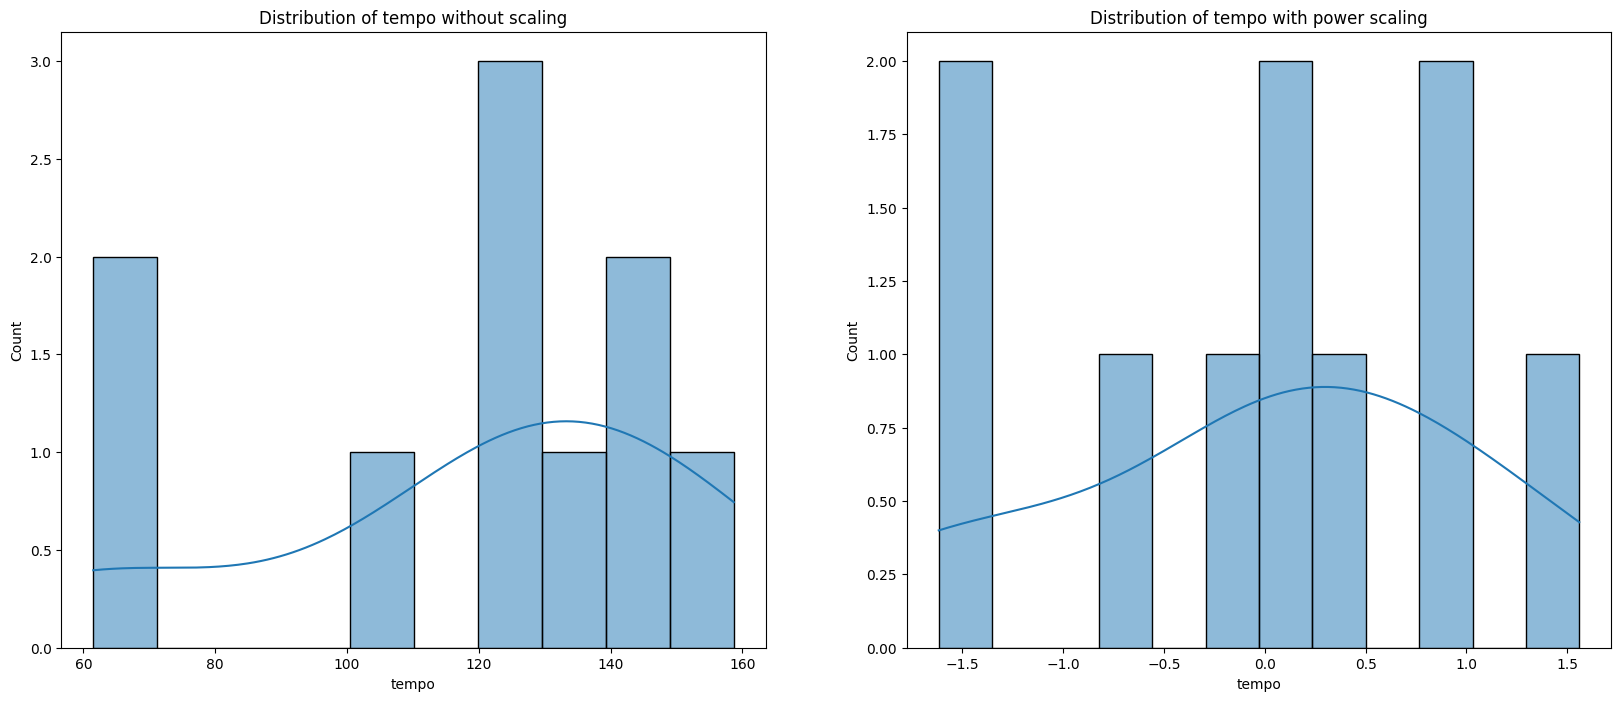

In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.histplot(data=selected_features_df.iloc[:,-1], bins=10, kde=True, ax=ax1);
sns.histplot(with_tempo_power.iloc[:,-1], bins=12, kde=True, ax=ax2);

ax1.set_title('Distribution of tempo without scaling')
ax2.set_title('Distribution of tempo with power scaling')

plt.show()

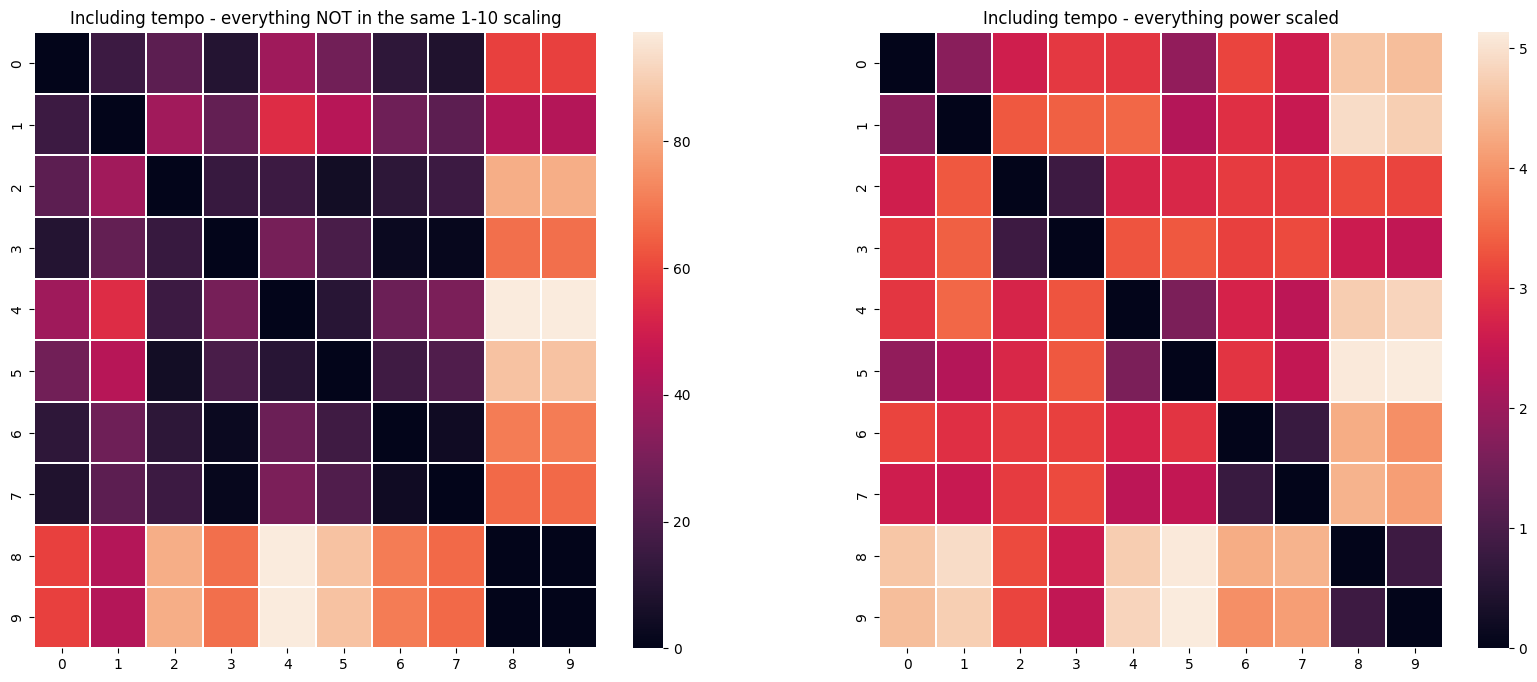

In [122]:
with_tempo_power_distances = pd.DataFrame(pairwise_distances(with_tempo_power),
                                         index=selected_features_df.index,
                                         columns=selected_features_df.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(with_tempo_distances_df, ax=ax1, linewidths=.2);
sns.heatmap(with_tempo_power_distances, ax=ax2, linewidths=.2);

ax1.set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax2.set_title('Including tempo - everything power scaled')

plt.show()

# COMPARING ALL 6 OPTIONS

## ALL 6 HISTOGRAMS FOR COMPARISON

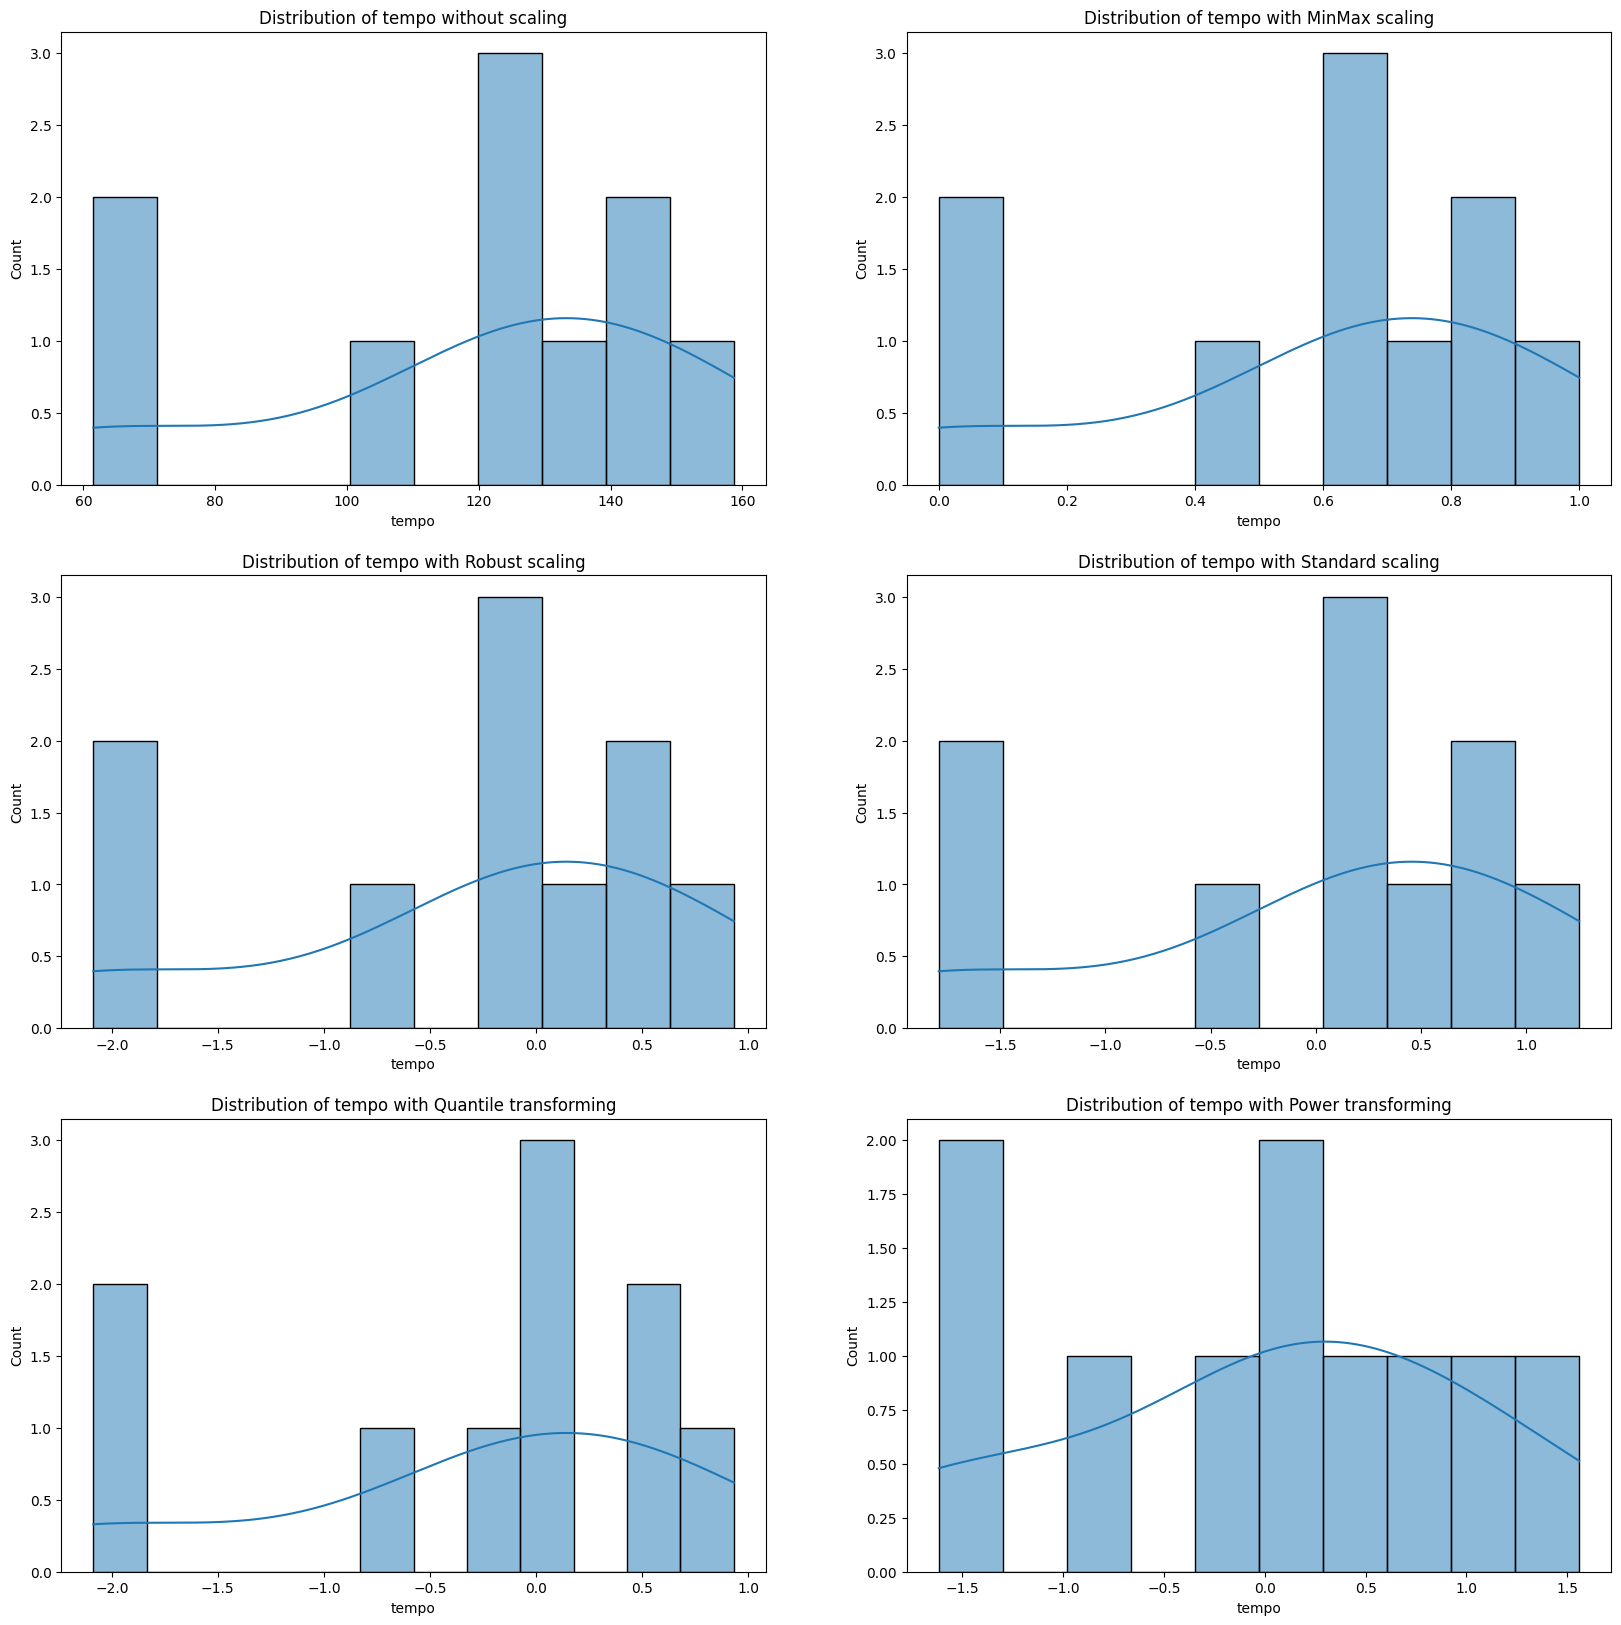

In [124]:
fig, ax = plt.subplots(3, 2, figsize=(20, 20))

sns.histplot(data=with_tempo_df.iloc[:,-1], bins=10, kde=True, ax=ax[0, 0]);
sns.histplot(data=with_tempo_minmax.iloc[:,-1], bins=10, kde=True, ax=ax[0, 1]);
sns.histplot(data=with_tempo_standard.iloc[:,-1], bins=10, kde=True, ax=ax[1, 1]);
sns.histplot(data=with_tempo_robust.iloc[:,-1], bins=10, kde=True, ax=ax[1, 0]);
sns.histplot(data=with_tempo_quantile.iloc[:,-1], bins=12, kde=True, ax=ax[2, 0]);
sns.histplot(data=with_tempo_power.iloc[:,-1], bins=10, kde=True, ax=ax[2, 1]);

ax[0, 0].set_title('Distribution of tempo without scaling')
ax[0, 1].set_title('Distribution of tempo with MinMax scaling')
ax[1, 0].set_title('Distribution of tempo with Robust scaling')
ax[1, 1].set_title('Distribution of tempo with Standard scaling')
ax[2, 0].set_title('Distribution of tempo with Quantile transforming')
ax[2, 1].set_title('Distribution of tempo with Power transforming')

plt.show()

## ALL 6 HISTOGRAMS FOR COMPARISON

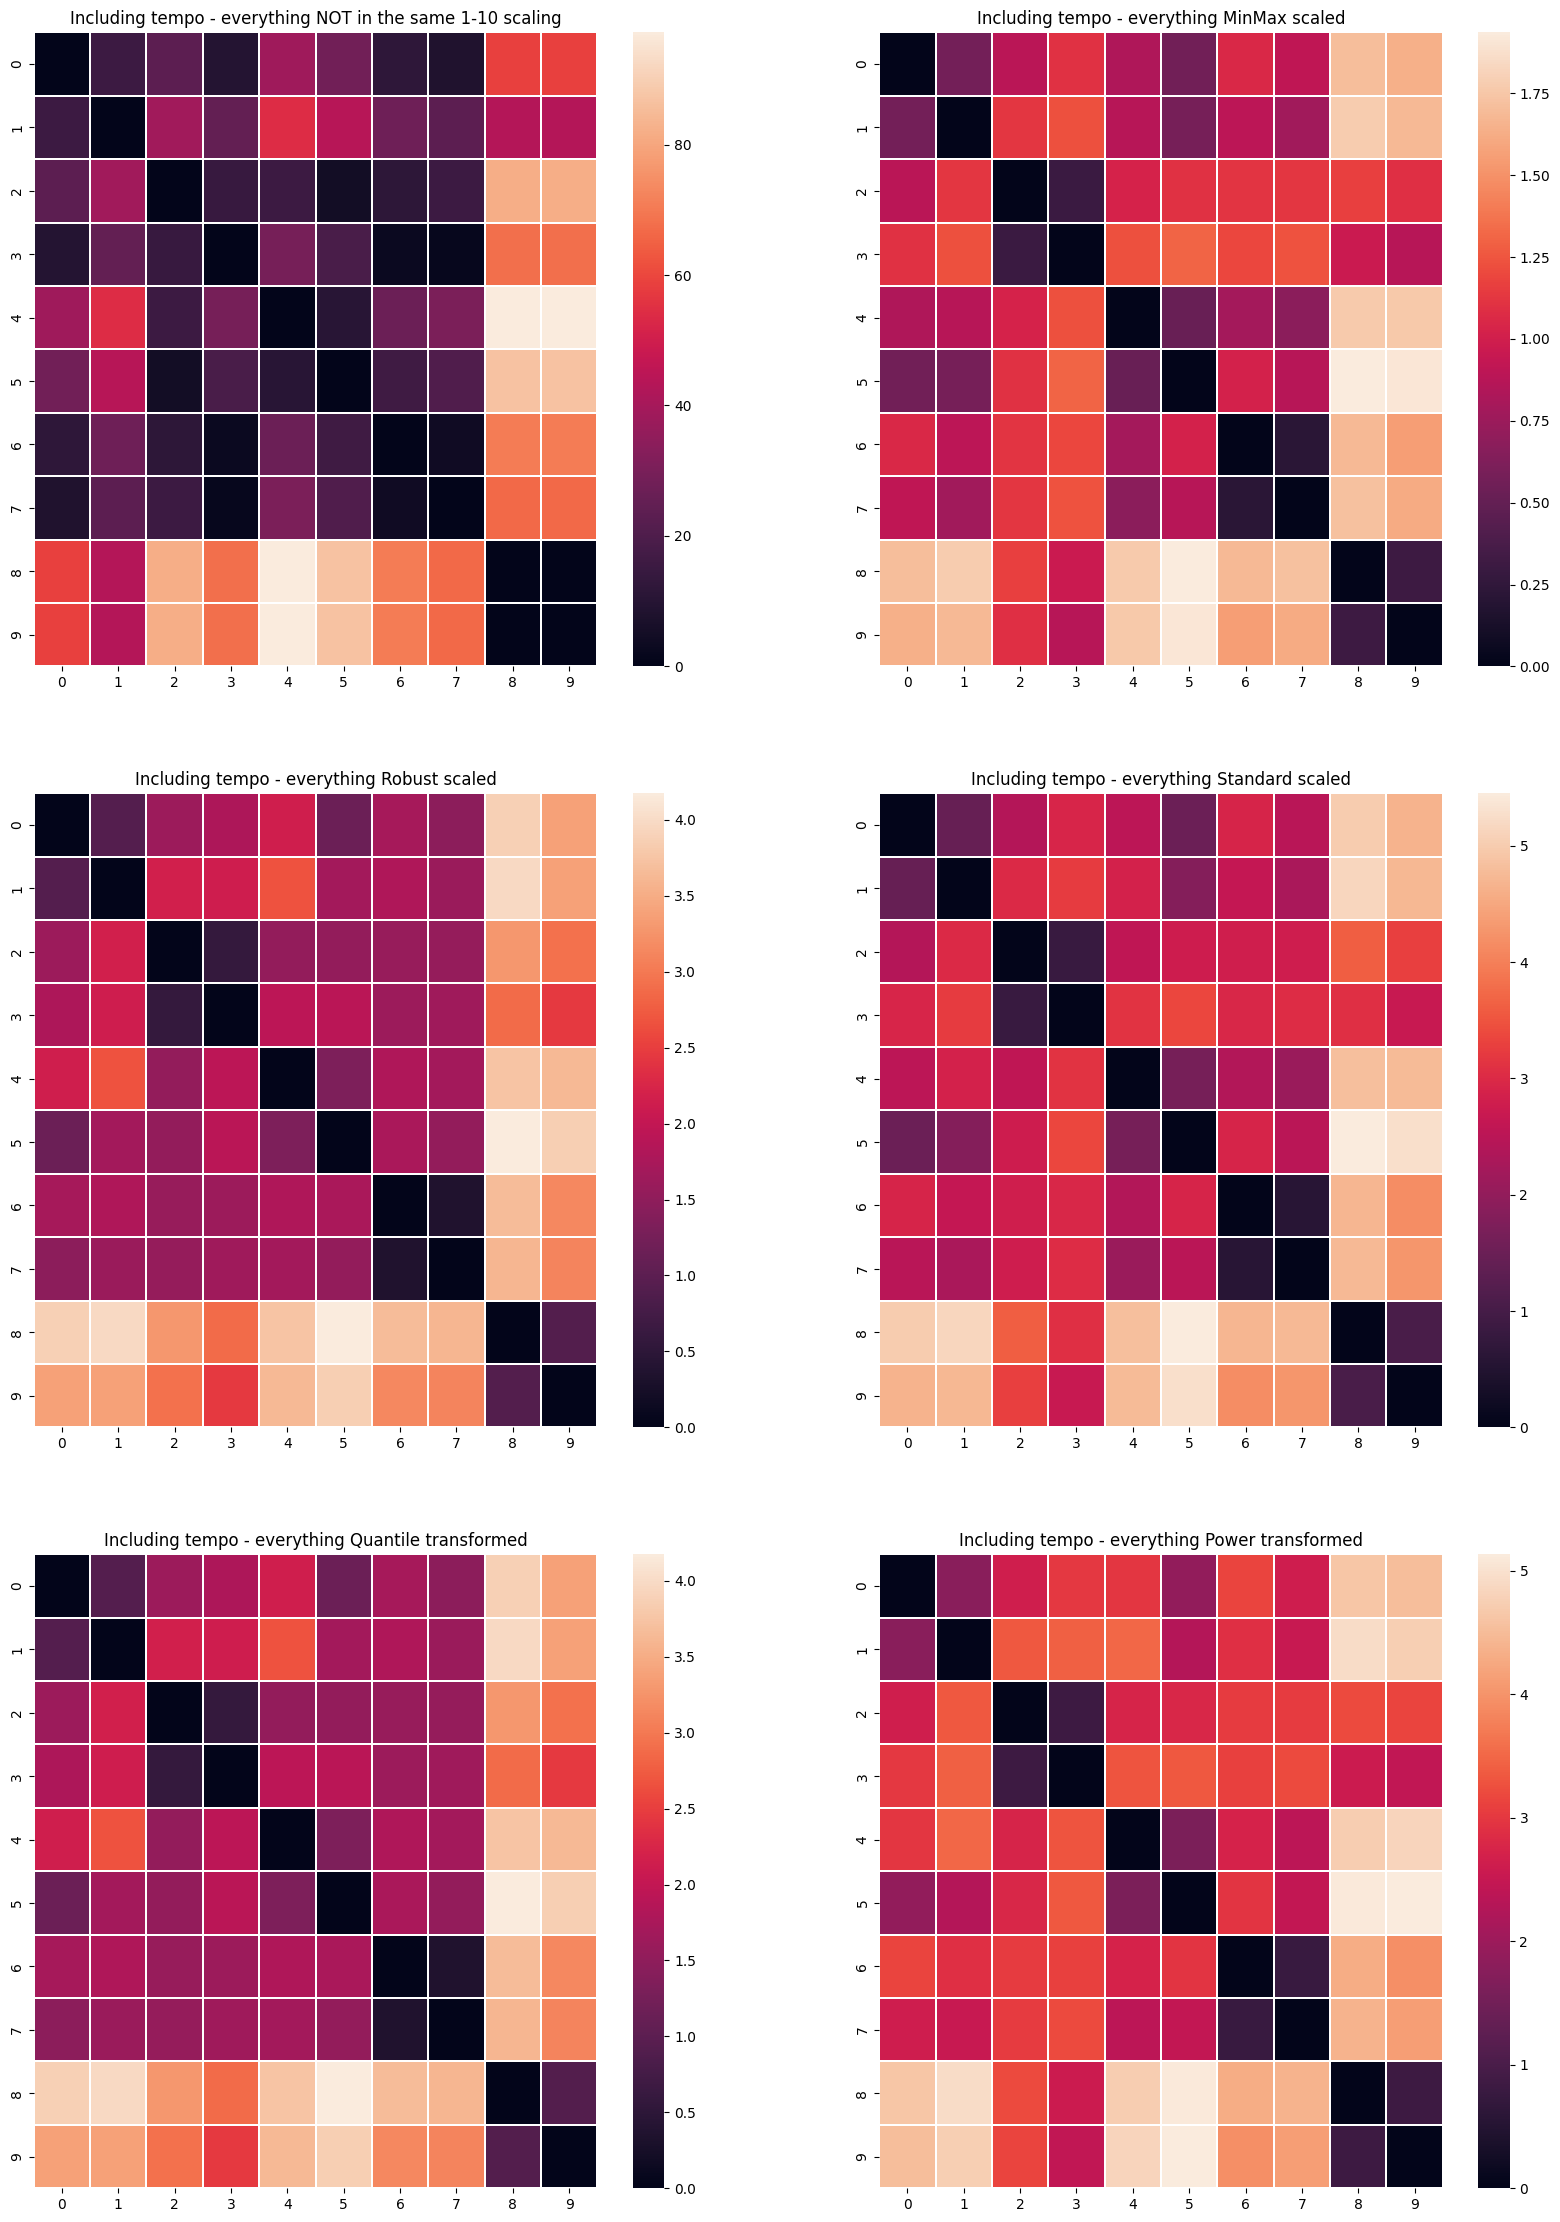

In [126]:
fig, ax = plt.subplots(3, 2, figsize=(20, 28))

sns.heatmap(with_tempo_distances_df, ax=ax[0, 0], linewidths=.2);
sns.heatmap(with_tempo_minmax_distances, ax=ax[0, 1], linewidths=.2);
sns.heatmap(with_tempo_robust_distances, ax=ax[1, 0], linewidths=.2);
sns.heatmap(with_tempo_standard_distances, ax=ax[1, 1], linewidths=.2);
sns.heatmap(with_tempo_quantile_distances, ax=ax[2, 0], linewidths=.2);
sns.heatmap(with_tempo_power_distances, ax=ax[2, 1], linewidths=.2);

ax[0, 0].set_title('Including tempo - everything NOT in the same 1-10 scaling')
ax[0, 1].set_title('Including tempo - everything MinMax scaled')
ax[1, 0].set_title('Including tempo - everything Robust scaled')
ax[1, 1].set_title('Including tempo - everything Standard scaled')
ax[2, 0].set_title('Including tempo - everything Quantile transformed')
ax[2, 1].set_title('Including tempo - everything Power transformed')

plt.show()